In [1]:
import jax
import jax.numpy as jnp, jax.random as jr

import matplotlib.pyplot as plt

In [2]:
foo = jnp.ones(5, dtype=jnp.float16)

In [3]:
from msvgd import MSVGD

In [4]:
a = 1
b = 1

def rosenbrock_logdensity(x, T):
    """
    Log-density of the 2D Rosenbrock distribution.
    x : shape (2, 1) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    x1, x2 = x
    return jnp.array([
        -(a - x1) ** 2
        - b*((x2 - x1 ** 2) ** 2)
    ]) / T

def gaussian_logdensity(x):
    """
    Log-density of the 2D Rosenbrock distribution.
    x : shape (2, 1) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    return jnp.array([
        -x**2/2
    ])

In [5]:
n_modes = 6
radius  = 3.0
sigma2  = 0.15

# Mode centres arranged evenly around a circle
angles  = jnp.linspace(0, 2 * jnp.pi, n_modes, endpoint=False)
centres = jnp.stack([radius * jnp.cos(angles),
                     radius * jnp.sin(angles)], axis=1)   # (n_modes, 2)

def ring_mixture_logdensity(x, T):
    """
    x : (2,) — as expected by MSVGD
    returns : (1,)
    """
    # Log of sum of Gaussians, computed stably via logsumexp
    log_weights = jnp.zeros(n_modes)                       # uniform mixture
    sq_dists = jnp.sum((centres - x) ** 2, axis=1)   # (n_modes,)
    log_kernels = -sq_dists / (2 * sigma2)                 # (n_modes,)
    return jnp.array([jax.nn.logsumexp(log_weights + log_kernels)]) / T

In [19]:
k = 200
key = jr.PRNGKey(101)
x0 = jr.normal(key, shape=(200, 2)) * 10

for i, T in enumerate(jnp.arange(20, 0, -1)):
    solver = MSVGD(lambda x: ring_mixture_logdensity(x, T))
    x0 = solver.solve(x0, mitosis_splits=max([2-i, 0]))

Split 0 finished after 3097 iterations | max grad = 0.00999
Split 1 finished after 1 iterations | max grad = 0.00991
Split 2 finished after 1 iterations | max grad = 0.00985
Split 0 finished after 21 iterations | max grad = 0.00998
Split 1 finished after 1 iterations | max grad = 0.00992
Split 0 finished after 17 iterations | max grad = 0.00999
Split 0 finished after 15 iterations | max grad = 0.00998
Split 0 finished after 13 iterations | max grad = 0.00996
Split 0 finished after 12 iterations | max grad = 0.00992
Split 0 finished after 11 iterations | max grad = 0.00994
Split 0 finished after 13 iterations | max grad = 0.00997
Split 0 finished after 23 iterations | max grad = 0.00994
Split 0 finished after 20 iterations | max grad = 0.00993
Split 0 finished after 21 iterations | max grad = 0.00993
Split 0 finished after 21 iterations | max grad = 0.00995
Split 0 finished after 28 iterations | max grad = 0.00991
Split 0 finished after 31 iterations | max grad = 0.00989
Split 0 finishe

In [20]:
particles = solver.particles

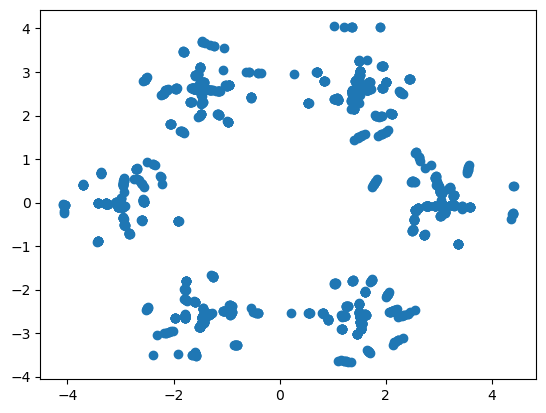

In [21]:
plt.scatter(particles[:,0], particles[:,1])

In [10]:
solver.particles.shape

(1600, 2)